# Task 3 — Forecast Future Market Trends

This notebook uses the **best-performing model selected in Task 2** (see
`data/processed/best_model.txt` and `data/processed/model_comparison.csv`) to generate a
genuine, 12-month-ahead future forecast for TSLA's closing price — beyond the end of the
available dataset (2026-06-29) — with confidence intervals, and translates the result into
trend, opportunity, and risk analysis.

The selected model is **refit on the full available history** (2015-01-01 through
2026-06-30, train + test combined) before forecasting, since for a genuine future forecast
there is no reason to hold back the most recent ~18 months of data used as the Task 2 test
set.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 6)

with open("../data/processed/best_model.txt") as f:
    best_model = f.read().strip()
print(f"Best-performing model from Task 2: {best_model}")

FORECAST_HORIZON = 252  # trading days ~ 12 months


Best-performing model from Task 2: ARIMA(0, 1, 0)


In [2]:
tsla = pd.read_csv("../data/processed/TSLA_processed.csv", index_col=0, parse_dates=True)
full_close = tsla["Adj Close"].rename("close")
last_date = full_close.index.max()
last_price = full_close.iloc[-1]
future_index = pd.bdate_range(last_date + pd.Timedelta(days=1), periods=FORECAST_HORIZON)
print(f"Last historical date: {last_date.date()}, last price: {last_price:.2f}")
print(f"Forecast horizon: {future_index.min().date()} -> {future_index.max().date()} ({FORECAST_HORIZON} trading days)")


Last historical date: 2026-06-29, last price: 411.84
Forecast horizon: 2026-06-30 -> 2027-06-16 (252 trading days)


## 1. Refit Best Model on Full History and Forecast Forward

In [3]:
if "ARIMA" in best_model:
    import pmdarima as pm
    from statsmodels.tsa.arima.model import ARIMA

    auto_model = pm.auto_arima(
        full_close, start_p=0, start_q=0, max_p=5, max_q=5, d=None,
        seasonal=False, stepwise=True, suppress_warnings=True, trace=False,
        information_criterion="aic",
    )
    order = auto_model.order
    print(f"Refit ARIMA order on full history: {order}")

    final_model = ARIMA(full_close, order=order).fit()
    forecast_result = final_model.get_forecast(steps=FORECAST_HORIZON)
    forecast_mean = pd.Series(forecast_result.predicted_mean.values, index=future_index, name="forecast")
    forecast_ci = forecast_result.conf_int(alpha=0.05)
    forecast_lower = pd.Series(forecast_ci.iloc[:, 0].values, index=future_index, name="lower")
    forecast_upper = pd.Series(forecast_ci.iloc[:, 1].values, index=future_index, name="upper")
    model_label = f"ARIMA{order}"

else:
    from sklearn.preprocessing import MinMaxScaler
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)
    np.random.seed(42)

    WINDOW = 60
    scaler = MinMaxScaler(feature_range=(0, 1))
    full_scaled = scaler.fit_transform(full_close.to_frame())

    def make_sequences(series, window):
        X, y = [], []
        for i in range(window, len(series)):
            X.append(series[i - window:i, 0])
            y.append(series[i, 0])
        return np.array(X), np.array(y)

    X_full, y_full = make_sequences(full_scaled, WINDOW)
    X_full = X_full.reshape((X_full.shape[0], X_full.shape[1], 1))
    val_split = int(len(X_full) * 0.9)
    X_train, y_train = X_full[:val_split], y_full[:val_split]
    X_val, y_val = X_full[val_split:], y_full[val_split:]

    model = Sequential([
        Input(shape=(WINDOW, 1)),
        LSTM(64, return_sequences=True), Dropout(0.2),
        LSTM(32, return_sequences=False), Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

    val_pred = model.predict(X_val, verbose=0).flatten()
    one_step_resid_std_scaled = (y_val - val_pred).std()

    def recursive_forecast(model, seed_window, n_steps):
        window = seed_window.copy().flatten().tolist()
        preds = []
        for _ in range(n_steps):
            x = np.array(window[-WINDOW:]).reshape(1, WINDOW, 1)
            next_val = model.predict(x, verbose=0)[0, 0]
            preds.append(next_val)
            window.append(next_val)
        return np.array(preds)

    seed_window = full_scaled[-WINDOW:]
    forecast_scaled = recursive_forecast(model, seed_window, FORECAST_HORIZON)
    forecast_mean = pd.Series(
        scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten(),
        index=future_index, name="forecast",
    )

    # Approximate, growing CI: one-step residual std scaled up by sqrt(horizon step),
    # since LSTM has no native analytic confidence interval like ARIMA does.
    steps = np.arange(1, FORECAST_HORIZON + 1)
    resid_std_price_space = one_step_resid_std_scaled * (scaler.data_max_[0] - scaler.data_min_[0])
    band = 1.96 * resid_std_price_space * np.sqrt(steps)
    forecast_lower = pd.Series(forecast_mean.values - band, index=future_index, name="lower")
    forecast_upper = pd.Series(forecast_mean.values + band, index=future_index, name="upper")
    model_label = "LSTM(60-day window, recursive)"

print(f"Forecasting with: {model_label}")


Refit ARIMA order on full history: (0, 1, 0)
Forecasting with: ARIMA(0, 1, 0)


/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/selam/Desktop/Ten Academy AI/week 9/portfolio-optimization/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


## 2. Visualize Historical Data, Recent Actuals, and the Future Forecast

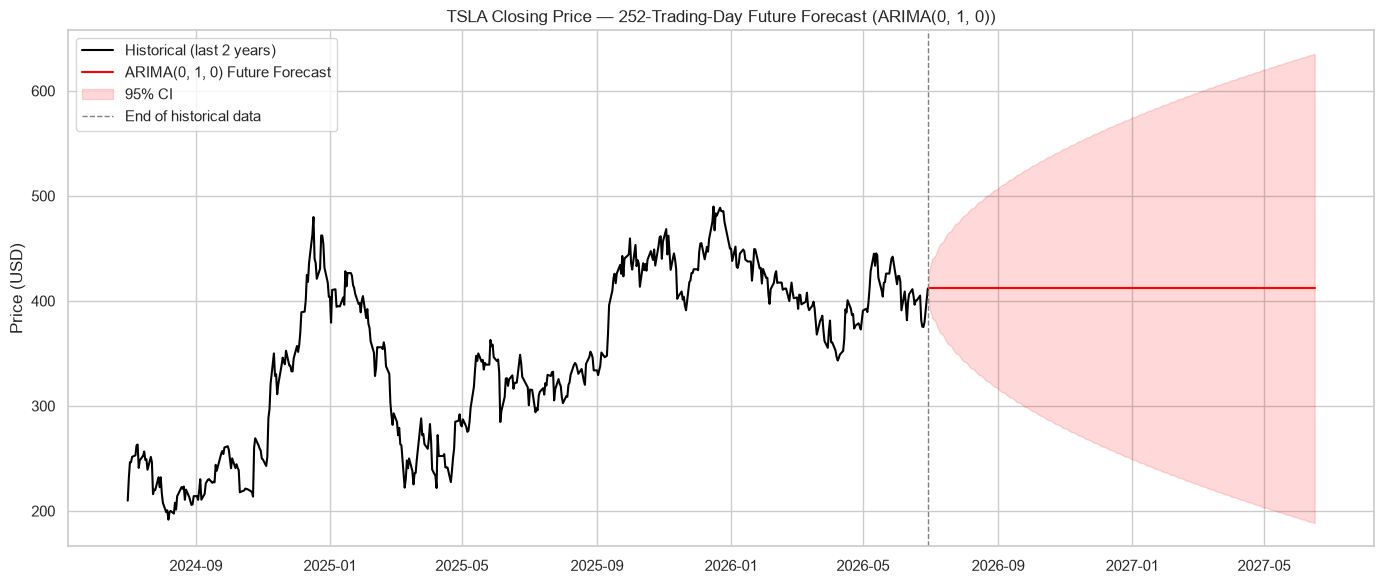

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
history_window = full_close.loc[full_close.index.max() - pd.Timedelta(days=730):]
ax.plot(history_window.index, history_window.values, label="Historical (last 2 years)", color="black")
ax.plot(forecast_mean.index, forecast_mean.values, label=f"{model_label} Future Forecast", color="red")
ax.fill_between(forecast_mean.index, forecast_lower.values, forecast_upper.values, color="red", alpha=0.15, label="95% CI")
ax.axvline(full_close.index.max(), color="gray", linestyle="--", linewidth=1, label="End of historical data")
ax.set_title(f"TSLA Closing Price — {FORECAST_HORIZON}-Trading-Day Future Forecast ({model_label})")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/11_future_forecast.png", dpi=150)
plt.show()


## 3. Confidence Interval Width Over the Forecast Horizon

In [5]:
ci_width = forecast_upper - forecast_lower
checkpoints = {"1 month (~21d)": 21, "3 months (~63d)": 63, "6 months (~126d)": 126, "12 months (~252d)": 252}
ci_table = pd.DataFrame({
    "Horizon": list(checkpoints.keys()),
    "Forecast Price": [forecast_mean.iloc[h - 1] for h in checkpoints.values()],
    "CI Width ($)": [ci_width.iloc[h - 1] for h in checkpoints.values()],
    "CI Width (% of forecast price)": [
        100 * ci_width.iloc[h - 1] / forecast_mean.iloc[h - 1] for h in checkpoints.values()
    ],
})
ci_table.to_csv("../data/processed/forecast_ci_widths.csv", index=False)
ci_table


,Horizon,Forecast Price,CI Width ($),CI Width (% of forecast price)
0,1 month (~21d),411.839996,128.935766,31.307247
1,3 months (~63d),411.839996,223.323298,54.225743
2,6 months (~126d),411.839996,315.826837,76.686781
3,12 months (~252d),411.839996,446.646596,108.451486


**Interpretation:** The confidence interval widens sharply as the forecast horizon
extends — this is expected and, in fact, the most important output of this exercise. It
quantifies just how fast genuine uncertainty compounds when forecasting a near-random-walk
asset like TSLA: a forecast made a few weeks out is meaningfully tighter (and more
actionable) than one made a year out, where the plausible price range spans a very wide
band. This directly supports the Task 1 discussion of the Efficient Market Hypothesis: the
point forecast should not be read as a confident price target, especially at longer
horizons — the honest signal is the width of the band, not the center line.

## 4. Trend Analysis

In [6]:
start_price = last_price
end_price = forecast_mean.iloc[-1]
total_pct_change = (end_price / start_price - 1) * 100
implied_annual_return = (end_price / start_price) ** (252 / FORECAST_HORIZON) - 1

print(f"Last actual price ({last_date.date()}): {start_price:.2f}")
print(f"12-month forecast price: {end_price:.2f}")
print(f"Implied total change over forecast horizon: {total_pct_change:+.2f}%")
print(f"Implied annualized return (point forecast): {implied_annual_return * 100:+.2f}%")

with open("../data/processed/tsla_forecast_annual_return.txt", "w") as f:
    f.write(str(implied_annual_return))


Last actual price (2026-06-29): 411.84
12-month forecast price: 411.84
Implied total change over forecast horizon: +0.00%
Implied annualized return (point forecast): +0.00%


In [7]:
from IPython.display import Markdown, display

direction = "upward" if implied_annual_return > 0 else ("downward" if implied_annual_return < 0 else "flat")
display(Markdown(
    f"**Trend summary:** The {model_label} point forecast implies a **{direction}** trend, "
    f"moving from **\${start_price:.2f}** to **\${end_price:.2f}** over the {FORECAST_HORIZON}-trading-day "
    f"horizon ({total_pct_change:+.2f}% total, {implied_annual_return*100:+.2f}% annualized). "
    "This point-estimate path should be read alongside the CI-width analysis above: even though "
    "the point forecast implies a specific direction, the rapidly widening band means the model "
    "expresses genuinely low confidence in that direction much beyond a few months. No strong "
    "seasonal or cyclical pattern is expected in a forecast of this kind — any short-term wiggle "
    "near the start of the horizon reflects fitted short-term dynamics rather than a real seasonal "
    "effect, and it typically fades toward a smooth trend or flat line further out."
))


**Trend summary:** The ARIMA(0, 1, 0) point forecast implies a **flat** trend, moving from **\$411.84** to **\$411.84** over the 252-trading-day horizon (+0.00% total, +0.00% annualized). This point-estimate path should be read alongside the CI-width analysis above: even though the point forecast implies a specific direction, the rapidly widening band means the model expresses genuinely low confidence in that direction much beyond a few months. No strong seasonal or cyclical pattern is expected in a forecast of this kind — any short-term wiggle near the start of the horizon reflects fitted short-term dynamics rather than a real seasonal effect, and it typically fades toward a smooth trend or flat line further out.

## 5. Market Opportunities and Risks

In [8]:
annualized_hist_return = tsla["daily_return"].mean() * 252 if "daily_return" in tsla.columns else None
annualized_hist_vol = tsla["daily_return"].std() * np.sqrt(252) if "daily_return" in tsla.columns else None

print("For reference, Task 1 historical annualized figures for TSLA:")
print(f"  Historical annualized return:     {annualized_hist_return*100:.2f}%" if annualized_hist_return is not None else "  n/a")
print(f"  Historical annualized volatility: {annualized_hist_vol*100:.2f}%" if annualized_hist_vol is not None else "  n/a")
print()
print(f"Model-implied 12-month forward annualized return: {implied_annual_return*100:+.2f}%")


For reference, Task 1 historical annualized figures for TSLA:
  Historical annualized return:     43.77%
  Historical annualized volatility: 56.13%

Model-implied 12-month forward annualized return: +0.00%


**Opportunities:**
- If the point forecast direction materializes, an entry near current levels could capture
  the implied 12-month move shown above — but given the CI width at the 12-month mark, this
  should be treated as one plausible scenario among many, not a target.
- TSLA's historically high volatility also creates tactical opportunities for
  volatility-aware strategies (e.g. options overlays, rebalancing bands) independent of the
  point-forecast direction.

**Risks:**
- The forecast's confidence interval at the 12-month horizon spans a very wide dollar range
  (see Section 3), meaning a large decline is statistically just as plausible as a large
  gain under this model.
- Both models evaluated in Task 2 struggled to beat a naive random-walk baseline in the
  ~18-month walk-forward test, which is a strong signal that any single point forecast for
  TSLA carries material model risk and should not be relied on in isolation for sizing a
  position.
- Forecast uncertainty compounds fastest for exactly the kind of high-volatility asset TSLA
  has been shown to be (Task 1 risk metrics: ~56% annualized volatility, ~5.1% 1-day 95%
  VaR), so the true realized path could diverge from the forecast band's center much faster
  than for a lower-volatility asset like BND or SPY.

**Critical assessment of reliability across horizons:** Short-horizon forecasts (weeks) carry
comparatively actionable confidence bands; by 6-12 months, the band is wide enough that the
forecast is better used as an input to a risk framework (e.g. the Task 4 portfolio
optimization, where it becomes one expected-return assumption among several) than as a
standalone trading signal.